In [ ]:
# import required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [74]:
# import data into a dataframe
df = pd.read_excel('salary_lab3.xlsx')
df

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344
1,1,1.4,46206
2,2,1.6,37732
3,3,2.1,43526
4,4,2.3,39892
5,5,3.0,56643
6,6,3.1,60151
7,7,3.3,54446
8,8,3.3,64446
9,9,3.8,57190


## Exploration

In [75]:
# run standard checks
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 852.0 bytes


In [76]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 852.0 bytes


In [78]:
df.shape

(30, 3)

In [79]:
df.duplicated().sum()

np.int64(0)

In [80]:
df.isna().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

## Cleaning

In [81]:
# drop unnecessary duplicated index column.
df_updated = df.drop('Unnamed: 0', axis=1)
df_updated

,YearsExperience,Salary
0,1.2,39344
1,1.4,46206
2,1.6,37732
3,2.1,43526
4,2.3,39892
5,3.0,56643
6,3.1,60151
7,3.3,54446
8,3.3,64446
9,3.8,57190


## Visualisation

<Axes: xlabel='YearsExperience', ylabel='Count'>

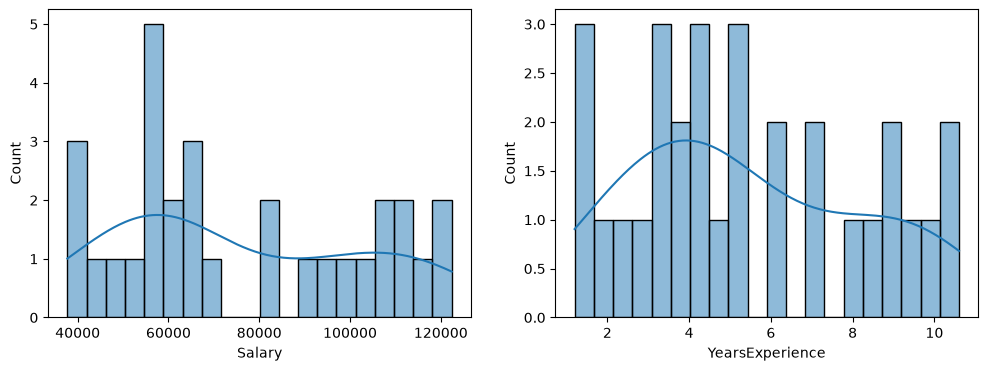

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


sns.histplot(data=df_updated, x='Salary', bins=20, kde=True, ax=axes[0])
sns.histplot(data=df_updated, x='YearsExperience', bins=20, kde=True, ax=axes[1])

<Axes: xlabel='YearsExperience'>

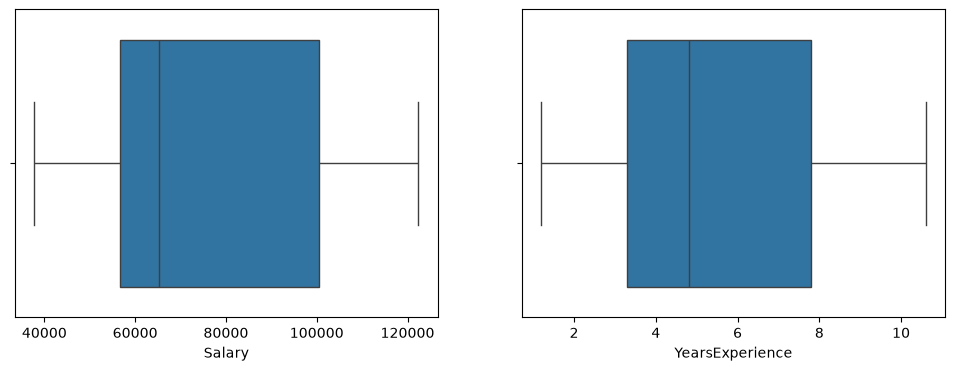

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


sns.boxplot(data=df_updated, x='Salary', ax=axes[0])
sns.boxplot(data=df_updated, x='YearsExperience', ax=axes[1])

<Axes: xlabel='YearsExperience', ylabel='Salary'>

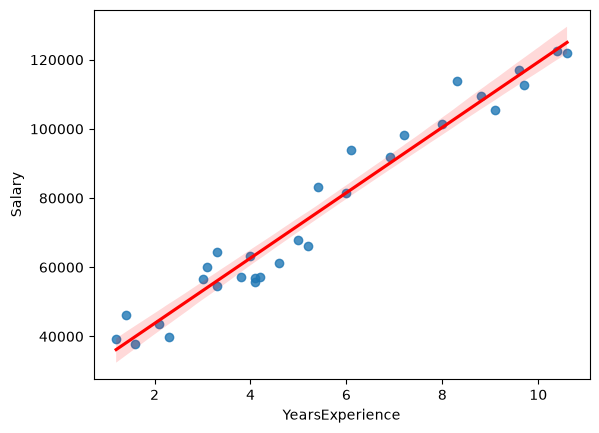

In [84]:
sns.regplot(data=df_updated, y='Salary', x='YearsExperience', line_kws={'color':'red'})

## Modelling

In [85]:
X = df_updated.drop('Salary', axis=1)
y = df_updated['Salary']
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=37
)

In [86]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9607.83]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.362e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [87]:
predictions = model.predict(x_test)
predictions

array([60125.24313069, 55321.32877472, 35144.88847965, 52438.98016114,
       53399.76303233])

In [88]:
print('MAE',metrics.mean_absolute_error(y_test,predictions))
print('MSE',metrics.mean_squared_error(y_test,predictions))
print('RMSE',np.sqrt(metrics.mean_squared_error(y_test,predictions)))


MAE 3792.988046458087
MSE 18053474.731921207
RMSE 4248.938071085669


<Axes: xlabel='Salary'>

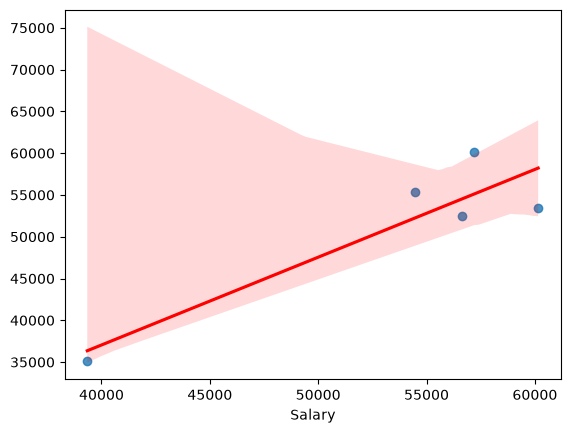

In [89]:
sns.regplot(x=y_test, y=predictions, line_kws={'color':'red'})

In [90]:
X_train_sm = sm.add_constant(x_train)
ols = sm.OLS(y_train, X_train_sm).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     473.0
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           7.72e-17
Time:                        16:22:38   Log-Likelihood:                -252.36
No. Observations:                  25   AIC:                             508.7
Df Residuals:                      23   BIC:                             511.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.362e+04   2886.489      8.181      0.000    1.76e+04    2.96e+04
YearsExperience  9607.8287    441.770     21.748      0.000    8693.957    1.05e+04
==============================================================================
Omnibus:                        2.534   Durbin-Watson:                   1.934
Prob(Omnibus):                  0.282   Jarque-Bera (JB):                1.962
Skew:                           0.537   Prob(JB):                        0.375
Kurtosis:                       2.146   Cond. No.                         15.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""